# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

from QickworkspaceV2.core.base_experiment import BaseExperiment

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

file_path = r'D:\Labber_Data\Jay\test'
BaseExperiment.setup(soc, soccfg, file_path)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a26a06964c834b27b9923f561f181a5d@192.168.10.82:41297
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# Qubit Setting

In [2]:
from QickworkspaceV2.tools.system_tool import ExperimentConfig
from QickworkspaceV2.config.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

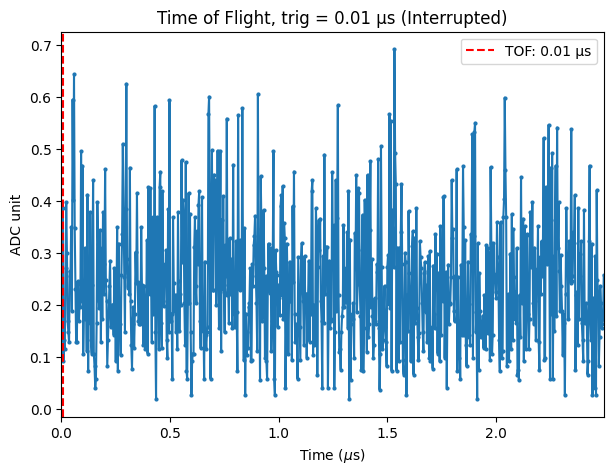

ExperimentData(type='s001_tof', id='7b08fbf5', quality=no_information, status=interrupted)

In [3]:
from QickworkspaceV2.experiments.setup import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        # "res_freq_ge": 3400,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 0.18,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": False,
        "relax_delay": 100,
    }
)

tof = TOF(run_cfg)
tof.run(1000)
# tof.saveLabber(qubit)

# YOKO Setting

In [ ]:
# from QickworkspaceV2.instruments.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [ ]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

c:\Users\cluster\Desktop\SQC_soc-main\QickworkspaceV2\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)
c:\Users\cluster\Desktop\SQC_soc-main\QickworkspaceV2\analysis\resonator.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


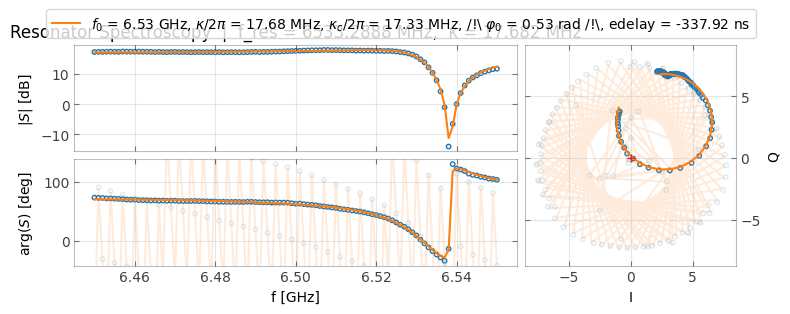

In [ ]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 100  # [MHz]
STOP_FREQ  = config_all.get_qubit(qubit)["res_freq_ge"] + 100  # [MHz]
START_FREQ = 6500-50  # [MHz]
STOP_FREQ  = 6500+50  # [MHz]


STEPS = 101

config_all.update("res.res_gain_ge", 0.4, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
result = onetone.run(py_avg=5, solve_type="hm")
## update value ##
config_all.update("res_freq_ge", result['f_res[MHz]'], q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

## OneTone PunchOut

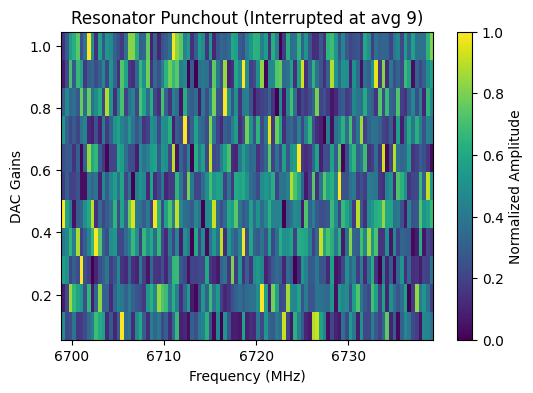

Experiment interrupted at 9 averages. Fit is based on partial data.


ExperimentData(type='s002b_res_ge_punchout', id='1e7fb267', quality=no_information, status=interrupted)

In [18]:
from QickworkspaceV2.experiments.resonator import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ  = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]

STEPS_freq = 101

START_gain = 0.1
STOP_gain  = 1
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
    ]
)
punchout = Punchout(run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
# punchout.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

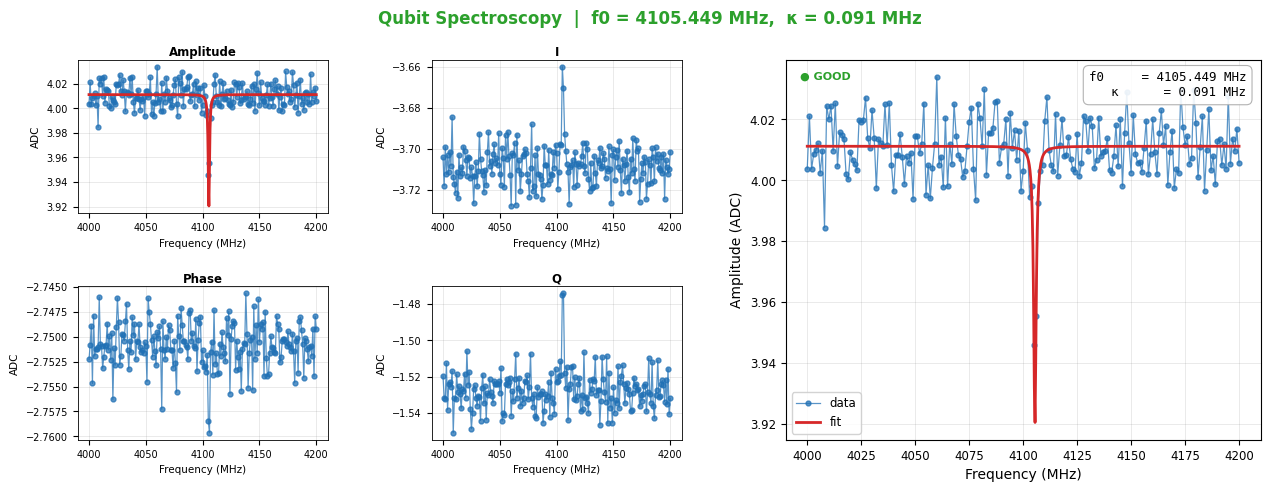

In [27]:
from QickworkspaceV2.experiments.qubit_ge import QubitSpec

center = 4100
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ  = center + SPAN  # [MHz]
STEPS = 201

config_all.update("qb_ch", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", 5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
    ]
)

spectrum_ge = QubitSpec(run_cfg)
spectrum_ge.run(50)
f_ge = spectrum_ge.result['f0_MHz']
# config_all.update("qb_freq_ge", f_ge, q_index=qubit)
# config_all.update("qb_mixer", f_ge, q_index=qubit)
# spectrum_ge.saveLabber(qubit, config_all=config_all)

### Fast flux spectrum

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import QubitSpecFlux

center = 5970
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ  = center + SPAN  # [MHz]
STEPS = 201

START_GAIN = -1
STOP_GAIN  = 1
STEPS_GAIN = 11

config_all.update("qb_ch", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.3),
        ("qb_flat_top_length_ge", 0.5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
        ("res_length", 3),
        ("ro_length", 2.478),
        ("res_gain_ge", 0.95),
        ("flux_ch", 15),
        ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
        ("steps_flux", STEPS_GAIN),
        ("flux_length", 0.7),
    ]
)

spectrumff_ge = QubitSpecFlux(run_cfg)
spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)

## Time Rabi ge

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import TimeRabi

config_all.update("sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 81),
    ]
)

Trabi = TimeRabi(run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 29 averages. Fit is based on partial data.


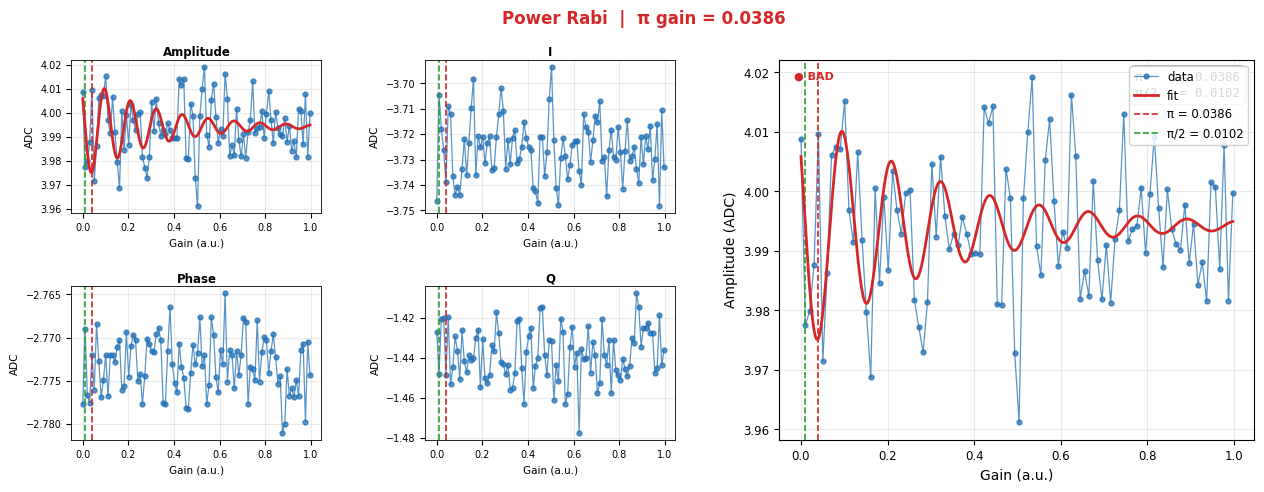

In [28]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN  = 1    # [DAC units]
STEPS = 100

config_all.update("sigma_ge", 0.15, q_index=qubit)
config_all.update("nqz_qb", 2, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        # ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.1),
    ]
)

prabi = PowerRabi(run_cfg)
prabi.run(50)
pi_gain, pi2_gain = prabi.result['pi_gain'], prabi.result['pi2_gain']
# config_all.update("pi_gain_ge", pi_gain, q_index=qubit)
# config_all.update("pi2_gain_ge", pi2_gain, q_index=qubit)
# prabi.saveLabber(qubit, config_all=config_all)

## Amplified Amplitude Error (AAE)

Interrupted at iteration 8.

[PowerRabi] Optimal pi gain = 0.015308


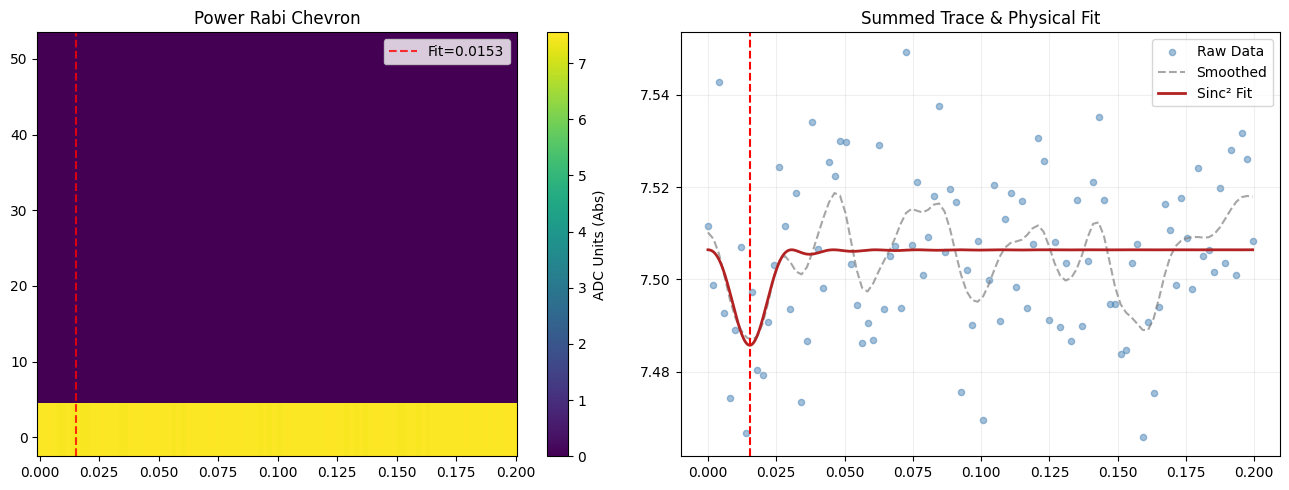

In [8]:
from QickworkspaceV2.experiments.qubit_ge import AAE

START_GAIN = 0.0  # [DAC units]
STOP_GAIN  = 1    # [DAC units]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
focus = run_cfg['pi_gain_ge']
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", focus - 0.1, focus + 0.1)),
        # ("pulse_type", "drag"),
        ("iter_start", 1),
        ("iter_stop", 50),
        ("iter_step", 7),
    ]
)

aae = AAE(run_cfg)
result = aae.run(10)
# config_all.update("pi_gain_ge", result, q_index=qubit)
# config_all.update("pi2_gain_ge", result / 2, q_index=qubit)
# aae.saveLabber(qubit, config_all=config_all)

## Ramsey ge

In [ ]:
from QickworkspaceV2.experiments.coherence import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME  = 1    # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 5),
        # ("pulse_type", "drag"),
    ]
)

t2r = Ramsey(run_cfg)
t2r.run(20)
t2r.saveLabber(qubit, config_all=config_all)

In [ ]:
config_all.update("qb_freq_ge", t2r.correct_detune(), qubit)

## Spin Echo

In [ ]:
from QickworkspaceV2.experiments.coherence import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0   # [us]
STOP_TIME  = 150   # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.05),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(run_cfg)
t2e.run(100)
t2e.saveLabber(qubit, config_all=config_all)

## T1 ge

In [ ]:
from QickworkspaceV2.experiments.coherence import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME  = 30   # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ("pulse_type", "drag"),
    ]
)

t1 = T1(run_cfg)
t1.run(50)
t1.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/5000 [00:00<?, ?it/s]

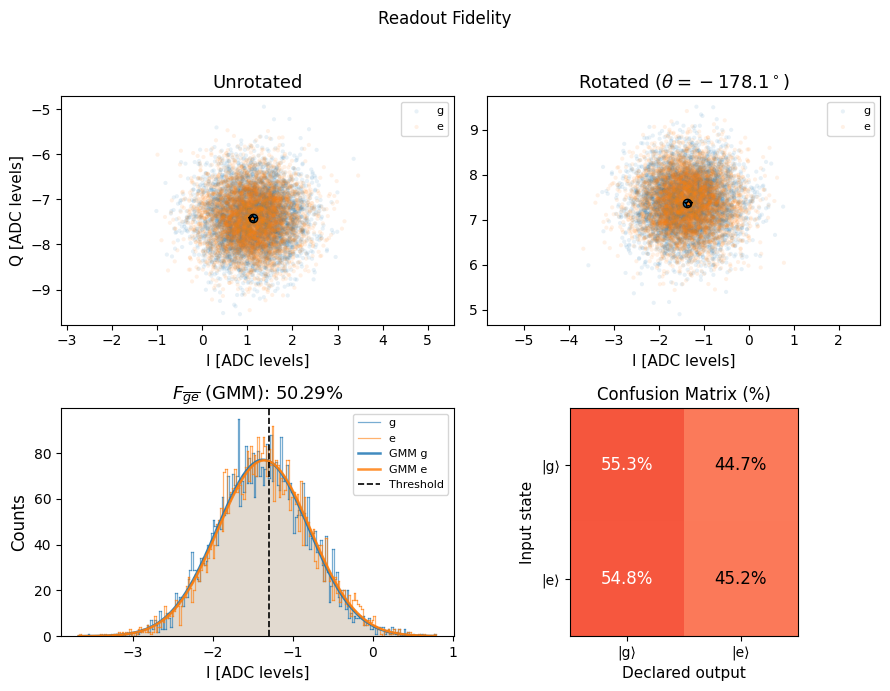

Rotation angle : -178.06 deg
GMM Fidelity   : 50.290%
  |g⟩  components=1  primary_mean=-1.375  primary_std=0.576  secondary_weight=0.000
  |e⟩  components=1  primary_mean=-1.358  primary_std=0.578  secondary_weight=0.000
Thresholds     : ['-1.298']
Confusion Matrix (%):
 [[55.3 44.7]
 [54.8 45.2]]


In [9]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

### run single shot with optimized parameters ###
config_all.update('res_phase', 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

# run_cfg['pulse_type'] = "drag"
SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update('res_phase', ssh_result[2], q_index=qubit)
# ssh.saveLabber(qubit)

### ssh opt

In [ ]:
from QickworkspaceV2.experiments.setup import SingleShot_ge_opt

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

freq_axis   = np.linspace(run_cfg["res_freq_ge"] - 2, run_cfg["res_freq_ge"] + 2, 4)
gain_axis   = np.linspace(0.4, 0.6, 7)
length_axis = np.linspace(0.5, 1.5, 11)
sweep_para  = {"freq": freq_axis, "gain": gain_axis, "length": length_axis}

SHOT = 2000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length",  length, q_index=qubit)
config_all.update("res_gain_ge", gain,  q_index=qubit)
config_all.update("res_freq_ge", freq,  q_index=qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase', 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=False)
ssh_result = ssh.plot(fid_avg=True, verbose=True)
config_all.update('res_phase', ssh_result[2], q_index=qubit)

# EF State

## Resonator OneTone ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ  = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
    ]
)

onetone_ef = ResonatorSpec_ef(run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", fres['f_res[MHz]'], q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import QubitSpecEf

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ  = center + SPAN  # [MHz]
STEPS = 101

config_all.update("qb_ch_ef", 0, q_index=qubit)
config_all.update("nqz_qb_ef", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.3),
        ("qb_flat_top_length_ef", 2),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpecEf(run_cfg)
result_ef = spectrum_ef.run(10)
f_ef = result_ef.scalar_result
config_all.update("qb_freq_ef",  f_ef, q_index=qubit)
config_all.update("qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import PowerRabiEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN  = 1    # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabiEf(run_cfg)
result_ef = prabi_ef.run(50)
pi_gain_ef  = result_ef['pi_gain']
pi2_gain_ef = result_ef['pi2_gain']
config_all.update("pi_gain_ef",  pi_gain_ef,  q_index=qubit)
config_all.update("pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

## Qubit Temperature ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import QubitTemp

START_GAIN = 0.0  # [DAC units]
STOP_GAIN  = 1    # [DAC units]
STEPS = 100

config_all.update("sigma_ef", 0.01, q_index=qubit)
config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
        ("ro_length", 2),
    ]
)

rabi_temp = QubitTemp(run_cfg)
rabi_temp.run(5)
# rabi_temp.saveLabber(qubit, config_all=config_all)

## Ramsey ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import RamseyEf

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME  = 2    # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ("ge_ref", True),
    ]
)

t2r_ef = RamseyEf(run_cfg)
t2r_ef.run(100)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [ ]:
config_all.update("qb_freq_ef", t2r_ef.correct_detune(), qubit)

## T1 ef

In [ ]:
from QickworkspaceV2.experiments.qubit_ef import T1Ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0   # [us]
STOP_TIME  = 400   # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
    ]
)

t1_ef = T1Ef(run_cfg)
t1_ef.run(50)
t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef (ef)

In [ ]:
from QickworkspaceV2.experiments.setup import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = 'drag'

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)

### ssh opt (ef)

In [ ]:
from QickworkspaceV2.experiments.setup import SingleShot_ge_opt

USE_DRAG = True

run_cfg = config_all.get_qubit(qubit)
if USE_DRAG:
    run_cfg['pulse_type'] = "drag"

freq_axis   = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 5, 4)
gain_axis   = np.linspace(0.05, 0.1, 3)
length_axis = np.linspace(1, 4, 4)
sweep_para  = {"freq": freq_axis, "gain": gain_axis, "length": length_axis}

SHOT = 1000
ssh_opt = SingleShot_ge_opt(run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para, shot_f=True)

### analyze and update config ###
length, gain, freq = ssh_opt.analyze()
config_all.update("ro_length",   length, q_index=qubit)
config_all.update("res_gain_ge", gain,   q_index=qubit)
config_all.update("res_freq_ge", freq,   q_index=qubit)

### run single shot with optimized parameters ###
config_all.update('res_phase', 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

if USE_DRAG:
    run_cfg['pulse_type'] = "drag"

SHOT = 5000
ssh = SingleShot_gef(run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True)

# AllXY

In [ ]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)

run_cfg.update([
    # ("pulse_type", "drag"),
])
allxy = AllXY(run_cfg)
allxy.run(10)
allxy.plot()

### Drag AllXY

In [ ]:
from QickworkspaceV2.experiments.characterization import AllXY

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("pulse_type", "drag"),
])
allxy = AllXY(run_cfg)
allxy.run(10, iq_process='real')
allxy.plot()

## State Tomography

In [ ]:
from QickworkspaceV2.experiments.characterization import Tomography

pyavg = 5

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(run_cfg)
tomo.run(py_avg=pyavg, prep_pulse_name="x180")
tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking

In [ ]:
from QickworkspaceV2.experiments.characterization import AutoRB

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"

auto = AutoRB(run_cfg)
interleaved = ["X", "X/2"]
auto.run(
    py_avg=5,
    max_circuit_depth=600,
    delta_clifford=50,
    number_sample=50,
    interleaved_gates=interleaved,
    iq_process='real'
)
auto.plot()
auto.saveLabber(qubit, config_all=config_all)
print(auto.summary())

In [ ]:
from QickworkspaceV2.experiments.characterization import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"

py_avg = 5
max_circuit_depth = 400
delta_clifford = 40
number_sample = 30

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
# interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]
interleaved_gates_to_test = ["X/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)

# Drag

In [ ]:
from QickworkspaceV2.experiments.qubit_ge import DragCalibration

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        # Alpha
        ("alpha_start",  -1),
        ("alpha_stop",   1.5),
        ("alpha_steps",  41),
        # Iterations
        ("iter_start",   2),
        ("iter_stop",    20),
        ("iter_step",    2),
    ]
)

drag_cal = DragCalibration(run_cfg)
fit_results = drag_cal.run(py_avg=5)

config_all.update("drag_alpha", fit_results['optimal_alpha'], q_index=qubit)
drag_cal.saveLabber(qubit, config_all=config_all)